In [1]:
import torch
from sparse_generalization.models.hypernet import HyperNetSpartan


saved_model = torch.load('../checkpoints/hypernet_test_seed0_27_Aug_2026__01h59m.pt', weights_only=False)
model = HyperNetSpartan(**saved_model['hparams'])
model.load_state_dict(saved_model['model'])

TypeError: HyperNetSpartan.__init__() got an unexpected keyword argument 'num_agg_layers'

In [36]:
a = torch.randn((32, 5, 16))
b = torch.randn((2, 16, 16))

# # out = a.view(2, 32, 5, 16) @ b.unsqueeze(1)
# out.shape

In [42]:
a.expand(2, -1, -1, -1).shape

torch.Size([2, 32, 5, 16])

(250, 2048)


/var/folders/h5/1rtlmq9x41bgl8btn0x1p6g80000gn/T/ipykernel_76548/1709204903.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


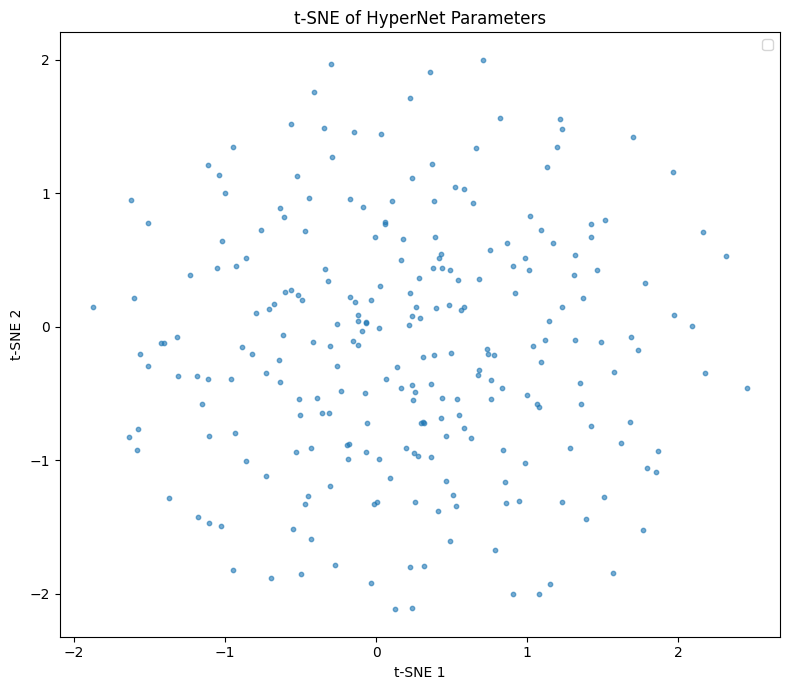

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch

model.eval()

all_params = []
num_samples = 250

with torch.no_grad():
    for _ in range(num_samples):
        x = torch.zeros((10, 10, 10))

        params, ladj = model.hyper_net.param_flow(x)

        all_params.append(params.cpu())

params = torch.cat(all_params).numpy()
print(params.shape)

tsne = TSNE(
    n_components=2,
    perplexity=50,
    random_state=42,
)

z = tsne.fit_transform(params)

plt.figure(figsize=(8, 7))

plt.scatter(
    z[:, 0],
    z[:, 1],
    s=10,
    alpha=0.6,
)
    

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of HyperNet Parameters")
plt.legend()
plt.tight_layout()
plt.show()
